## 🚀 Quick Start

This notebook shows the *minimum steps* needed to run a electrical network optimization in a wind farm via OptiWindNet.

### Steps

An network optimization via OptiWindNet involves two components:

* A `WindFarmNetwork` containing the problem data.
* A `Router` describing the method used to solve it.

The network optimization can be performed using following steps:

1) Create a `WindFarmNetwork` instance
2) Define a router
3) Run the optimization and get the results

#### 1. Create a `WindFarmNetwork` instance

The `WindFarmNetwork` component stores the turbine layout and runs optimization (storing the optimized network after running an optimization). See [WindFarmNetwork and Router](hi10_windfarmnetwork.ipynb) for some of the important methods and functionalities provided by this component.

In [1]:
from optiwindnet.api import WindFarmNetwork

In [2]:
import matplotlib.pyplot as plt
# Display figures as SVG in Jupyter notebooks
%config InlineBackend.figure_formats = ['svg']

##### Load location data

> Note: For details about *OptiWindNet*'s `load_repository()`, check [Load repositories containing location data](hi12_repositories.ipynb).

In [3]:
from optiwindnet.api import load_repository
locations = load_repository()
L = locations.doggerA

Initialize a `WindFarmNetwork` instance with a prebuilt `L` and a desired maximum cable capacity *(See [Data Input](hi11_data_input.ipynb) for various input formats.)*

In [4]:
wfn = WindFarmNetwork(L=L, cables=8)

We can plot the location to make sure `wfn` is created with the correct data.

>**Tip.**In a notebook, just put `wfn` as the last line of a cell for plotting G.
>
>* Before optimization (no `G` yet), it renders the location geometry `L`.
>* If `G` exists (e.g. after a `optimize()` is run), it automatically renders `G`.
>
>We could use `wfn.plot_location()` for plotting the location geometry. For more details look into the notebook about [plotting](hi13_plotting.ipynb)

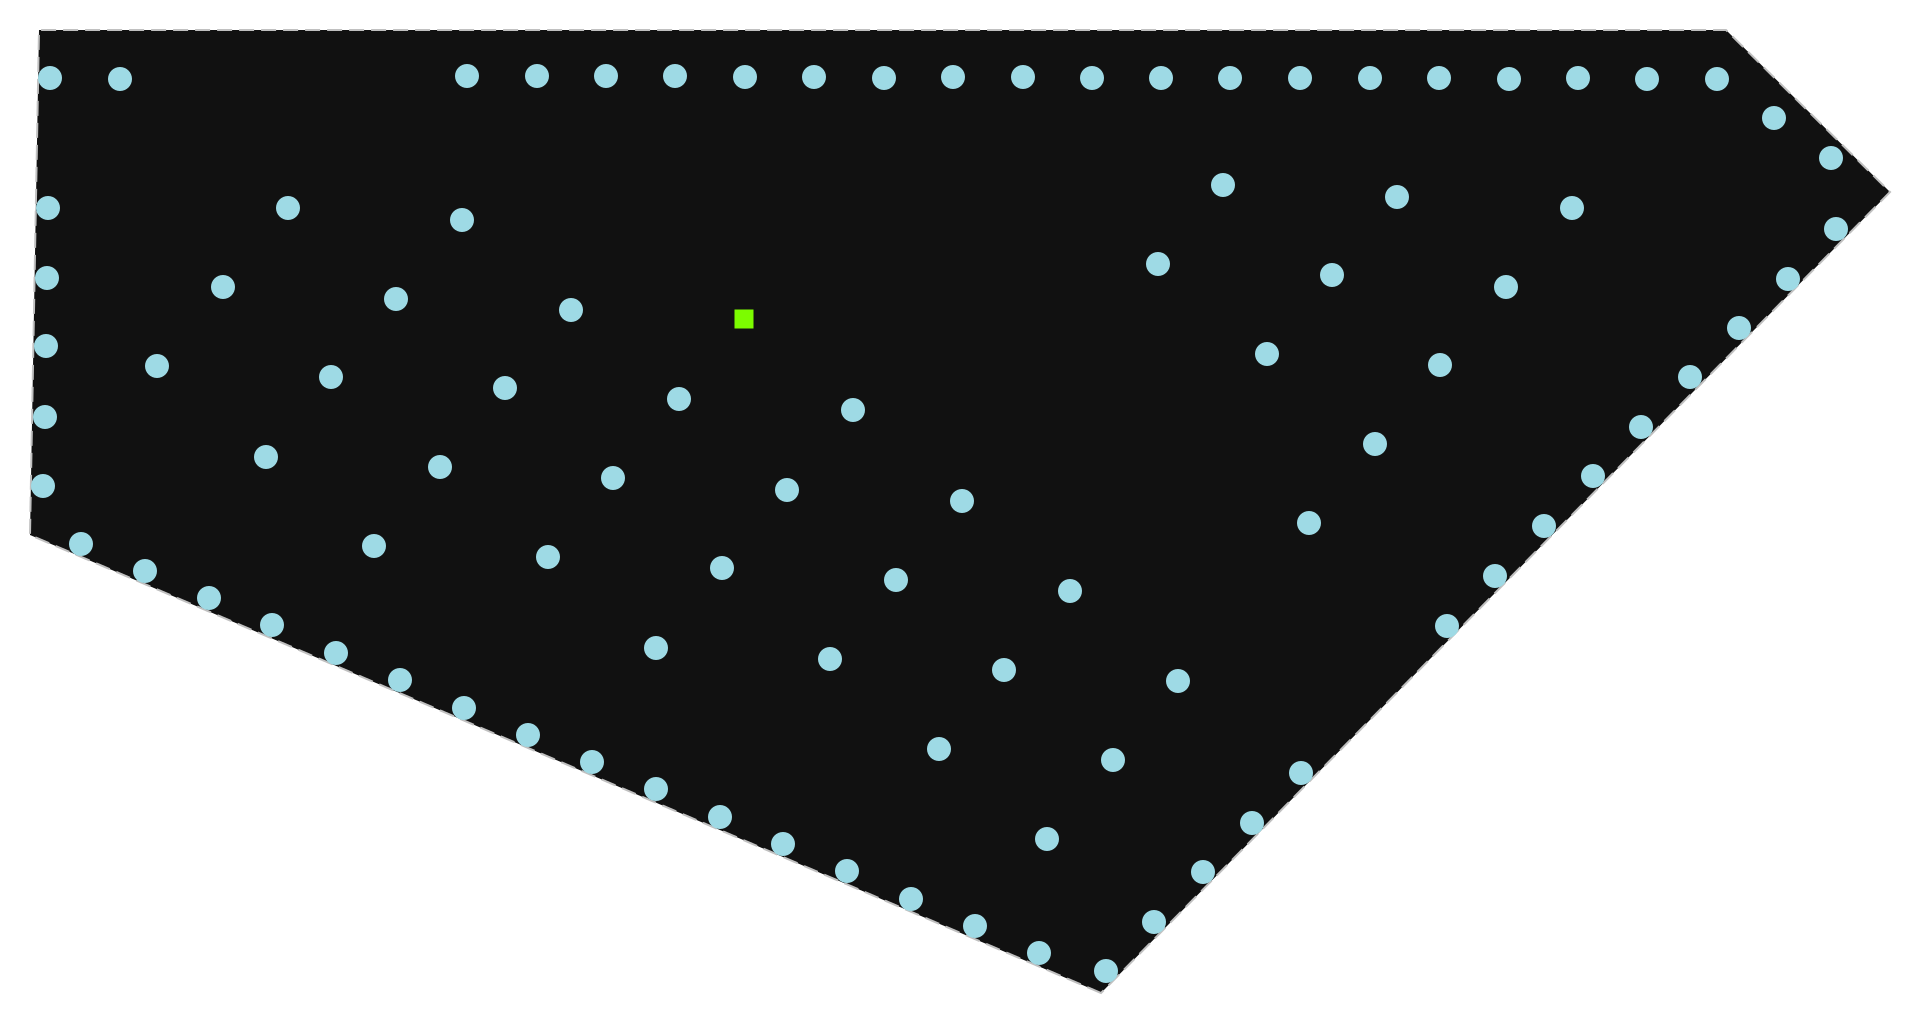

In [5]:
wfn

#### 2. Define a `Router`

Three built-in routers are available in *OptiWindNet*, one per solution method family:

| Router | Method family |
|---|---|
| `EWRouter` | constructive heuristic — sub-second |
| `HGSRouter` | meta-heuristic — you set the time budget |
| `MILPRouter` | exact optimization — reports an optimality gap |

Their trade-offs are compared in [The three families](../methods.md#the-three-families).
See [WindFarmNetwork and Router](hi10_windfarmnetwork.ipynb) for details about routers.

##### EWRouter

To use this router, simply create an instance of the `EWRouter` class. All arguments are *optional*, making it quick and easy to get started with minimal configuration.

In [6]:
from optiwindnet.api import EWRouter

In [7]:
ew_router = EWRouter()

##### HGSRouter

To use this router, create an instance of the `HGSRouter` class. The *only required argument* is `time_limit`, which defines how long the optimization is allowed to run (in seconds).

In [8]:
from optiwindnet.api import HGSRouter

In [9]:
hgs_router = HGSRouter(time_limit=1)

##### MILPRouter

To use this router, create an instance of the `MILPRouter` class.
You must provide:

* `solver_name`: the MILP solver to use (e.g., `'ortools.cp_sat'`, `'gurobi'`, `'cbc'`)
* `time_limit`: maximum time allowed for solving (in seconds)
* `mip_gap`: acceptable optimality gap (e.g., `0.005` = 0.5%)

Optional arguments:

* `verbose` *(default: False)*: set to `True` to display solver progress and detailed logs
* `solver_options`: dictionary of solver-specific parameters
* `model_options`: advanced model settings (e.g., topology, feeder configuration)

In [10]:
from optiwindnet.api import MILPRouter

In [11]:
milp_router = MILPRouter(solver_name='ortools.cp_sat', time_limit=20, mip_gap=0.005, verbose=True)

#### 3. Run the optimization

##### EWRouter (very fast)

In [12]:
%%timeit
res_ew = wfn.optimize(router=ew_router)

33.3 ms ± 694 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [13]:
wfn.solution_info()

{'router': 'EWRouter', 'capacity': 8, 'method': 'biased_EW', 'iterations': 84}

In [14]:
wfn.length()

261192.1342444766

Plot optimized network

> Note: we could use `wfn.plot()` for plotting the optimized network. For more details look into the notebook about [plotting](hi13_plotting.ipynb)

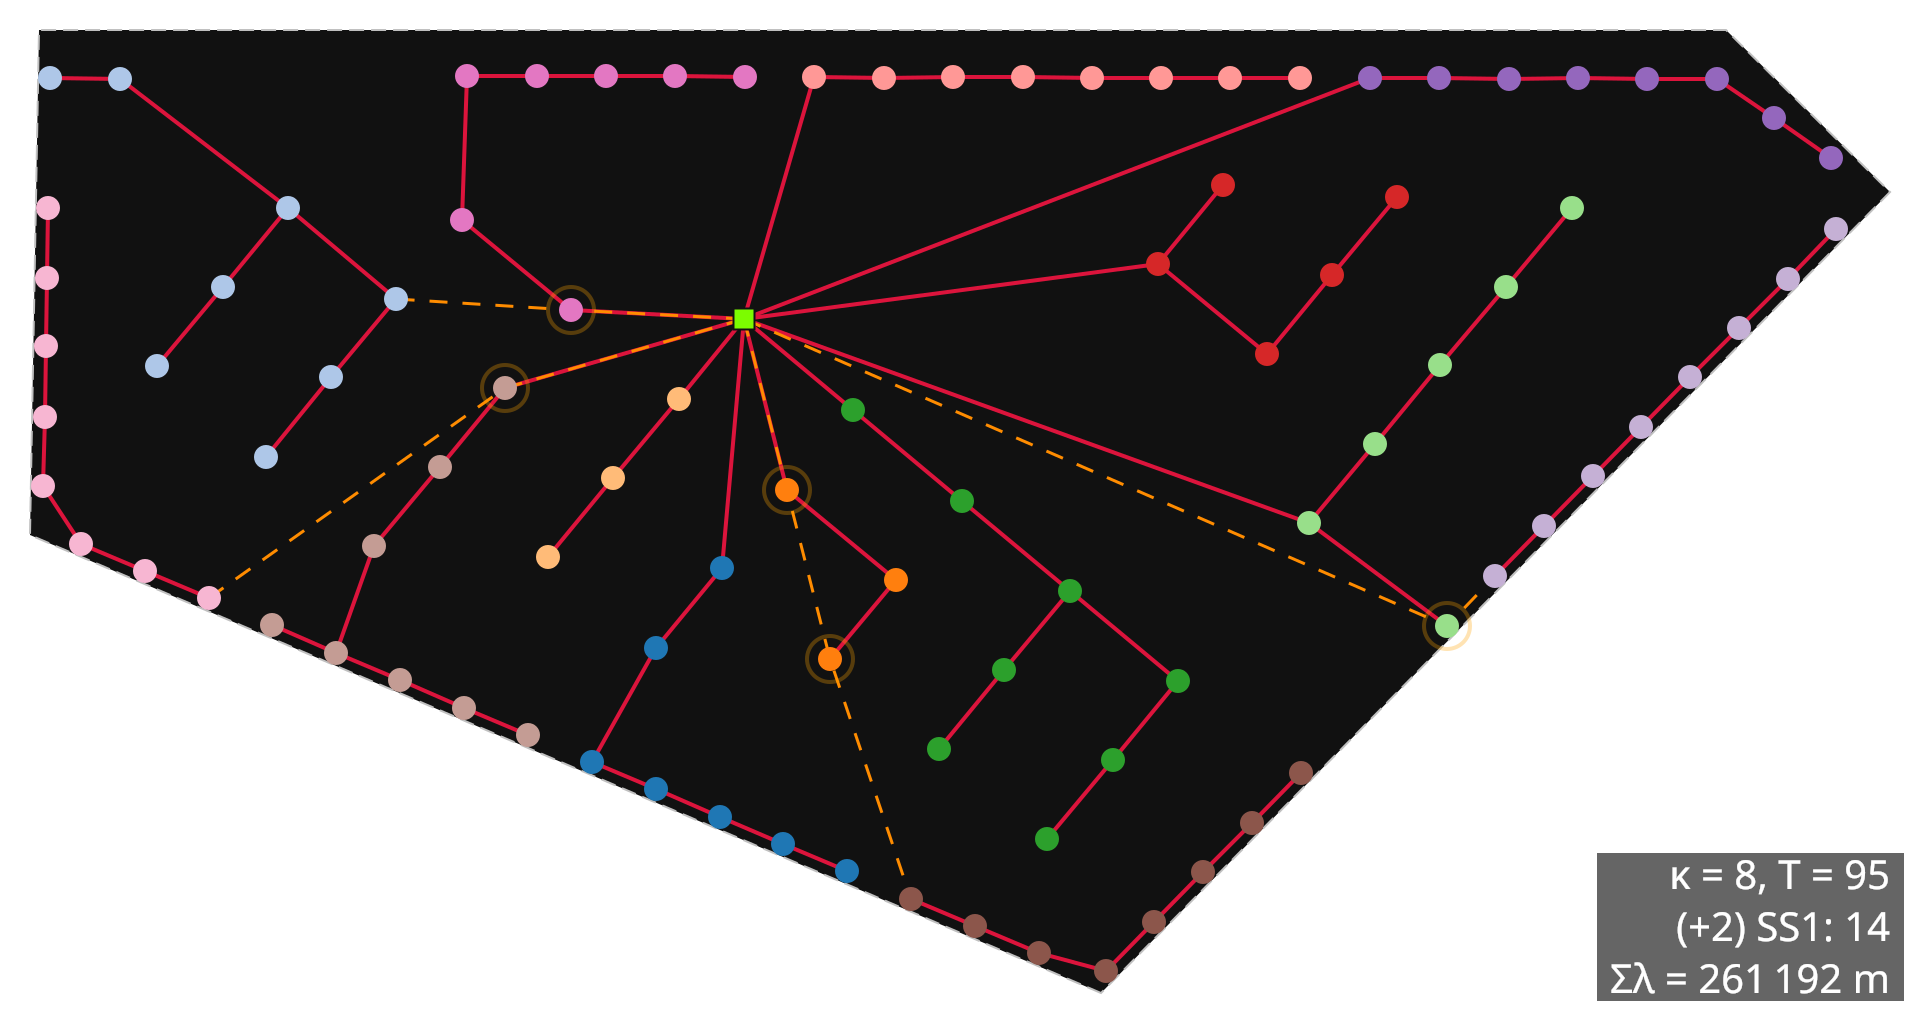

In [15]:
wfn

> **Note:**When calling `.optimize()` multiple times on the **same**`WindFarmNetwork` instance, the previously stored solution and related information (e.g., network graph, cost, length) will be **overwritten**.
> You can verify this by checking the updated total length or by re-plotting the optimized network and comparing it to the earlier result.

##### HGSRouter (fast - radial or ringed topology)

In [16]:
res_hgs = wfn.optimize(router=hgs_router)

In [17]:
wfn.solution_info()

{'router': 'HGSRouter',
 'capacity': 8,
 'solver_name': 'HGS-CVRP',
 'complete': False,
 'feeders_above_min': None,
 'feeders_exact': False,
 'nbGranular': 20,
 'mu': 25,
 'lambda_': 40,
 'nbElite': 4,
 'nbClose': 5,
 'nbIterPenaltyManagement': 100,
 'targetFeasible': 0.2,
 'penaltyDecrease': 0.85,
 'penaltyIncrease': 1.2,
 'seed': 625878960,
 'nbIter': 20000,
 'nbIterTraces': 500,
 'timeLimit': 1,
 'useSwapStar': True,
 'runtime': 1.000364848}

In [18]:
wfn.length()

243320.14066103278

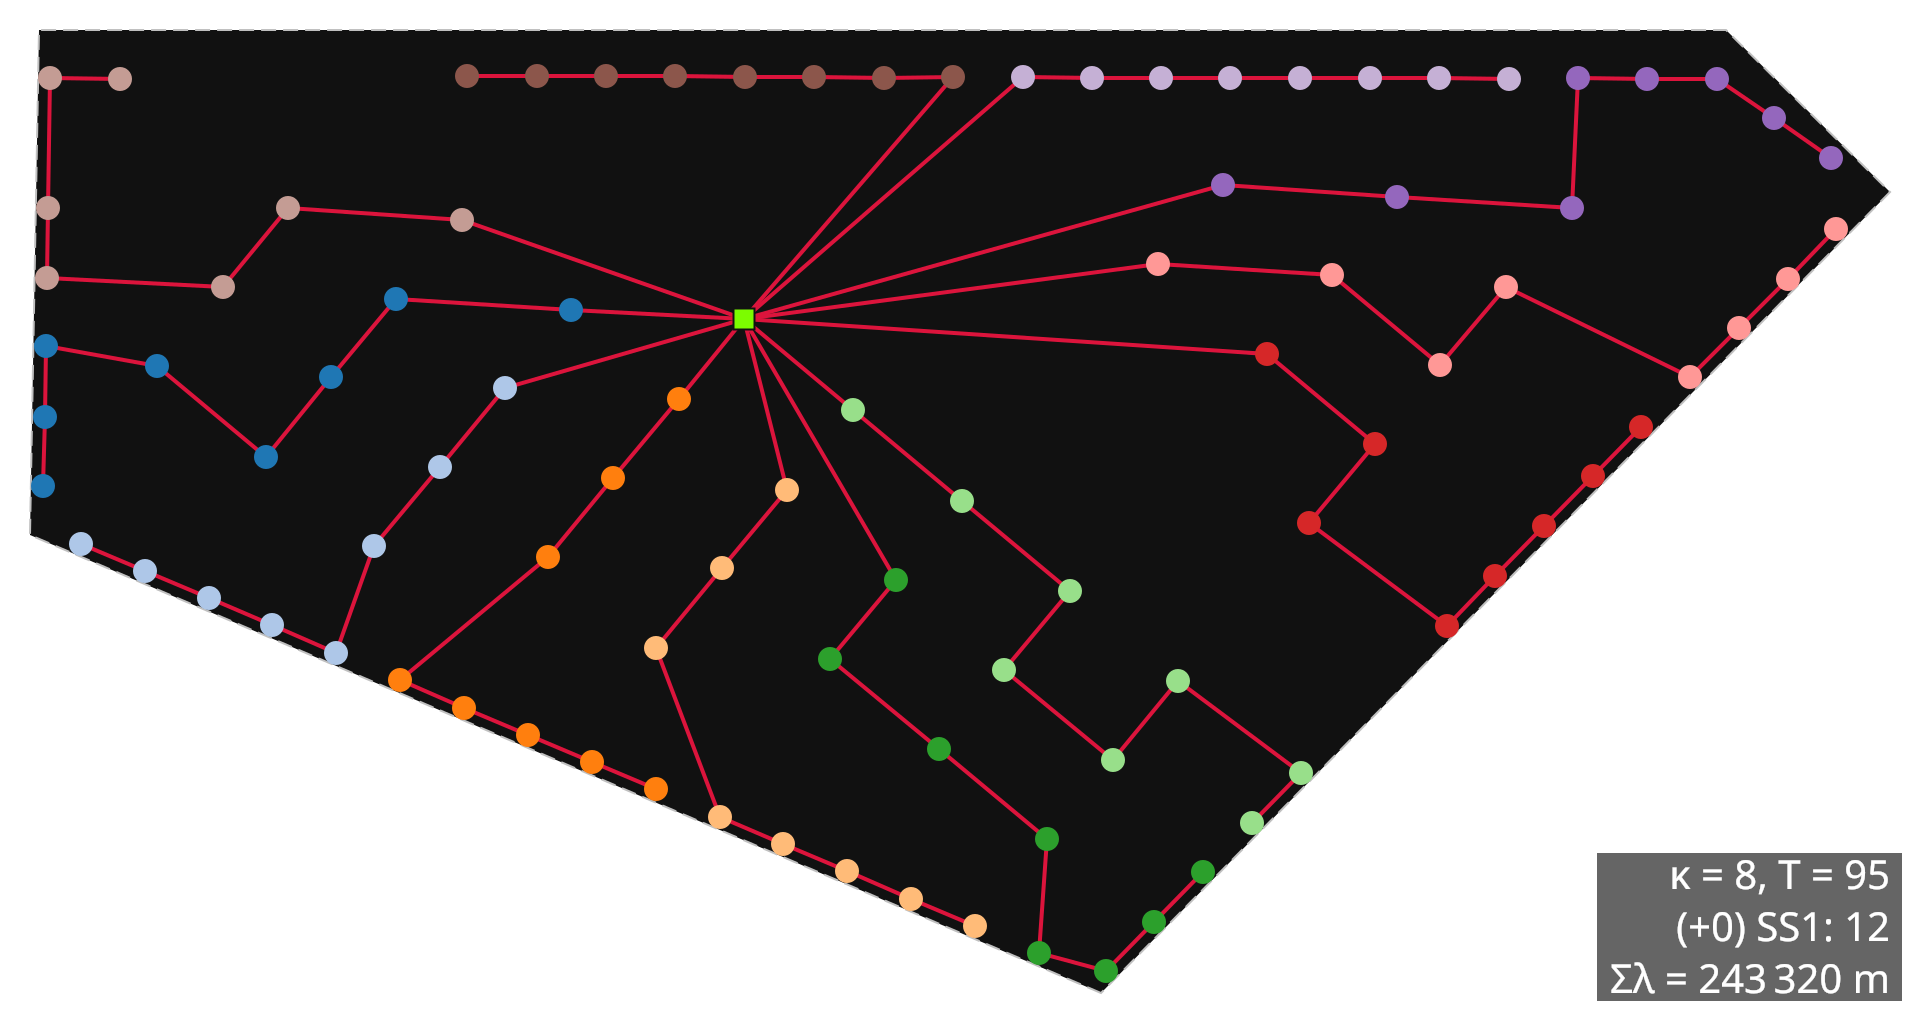

In [19]:
wfn

> Note that the HGSRouter produces a **radial**or **ringed***topology*, never a
> **branched**one. The three topologies are defined in
> [Network topologies](../problem.md#network-topologies); the figure below contrasts them.

In [20]:
from optiwindnet.synthetic import toyfarm
from optiwindnet.api import ModelOptions

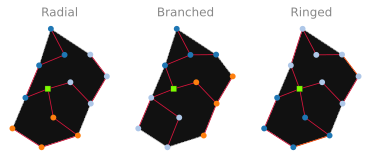

In [21]:
fig, (axl, axm, axr) = plt.subplots(1, 3, facecolor='none')

wfn_toy = WindFarmNetwork(L=toyfarm(), cables=4)
opt_milp = dict(mip_gap=0.001, time_limit=5, solver_name='ortools.cp_sat')

axl.set_title('Radial', color='#888888')
wfn_toy.optimize(
    router=MILPRouter(
        **opt_milp,
        model_options=ModelOptions(
            topology='radial',
            feeder_limit='minimum',
        )
    )
)
wfn_toy.plot(ax=axl, infobox=False)

axm.set_title('Branched', color='#888888');
wfn_toy.optimize(
    router=MILPRouter(
        **opt_milp,
        model_options=ModelOptions(
            topology='branched',
            feeder_limit='minimum',
        )
    )
)
wfn_toy.plot(ax=axm, infobox=False);

axr.set_title('Ringed', color='#888888');
wfn_toy.optimize(
    router=MILPRouter(
        **opt_milp,
        model_options=ModelOptions(
            topology='ringed',
            feeder_limit='minimum',
        )
    )
)
wfn_toy.plot(ax=axr, infobox=False);

##### MILPRouter


(high-quality solutions with guarantees, may take several minutes)

> Note:
> * if a `WindFarmNetwork` already has a solution, `MILPRouter` will use it as a warm start — see [Warm-starting](../methods.md#warm-starting) for which solutions are usable with which model.
> * To avoid warm-starting, create a **new**`WindFarmNetwork` and run MILP directly.
> * Set `verbose=True` to see warm-start messages in the logs.

In [22]:
res_milp = wfn.optimize(router=milp_router)

IntegerBoundsPreprocessor                              2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
BoundPropagationPreprocessor                           2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
ImpliedIntegerPreprocessor                             2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
IntegerBoundsPreprocessor                              2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        2613 rows, 1690 columns, 9531 entries with magnitude in [1.000000e+00, 8.000000e+00]

Scaling to pure integer problem.
Num integers: 1690/1690 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: max_t

In [23]:
wfn.solution_info()

{'router': 'MILPRouter',
 'capacity': 8,
 'solver_name': 'ortools.cp_sat',
 'mip_gap': 0.005,
 'time_limit': 20,
 'topology': <Topology.BRANCHED: 'branched'>,
 'feeder_route': <FeederRoute.SEGMENTED: 'segmented'>,
 'feeder_limit': <FeederLimit.UNLIMITED: 'unlimited'>,
 'balanced': False,
 'runtime': 20.118368,
 'bound': 229770.81284854643,
 'objective': 241104.1441382699,
 'relgap': 0.04700595806940577,
 'termination': 'FEASIBLE'}

In [24]:
wfn.length()

241104.1441382698

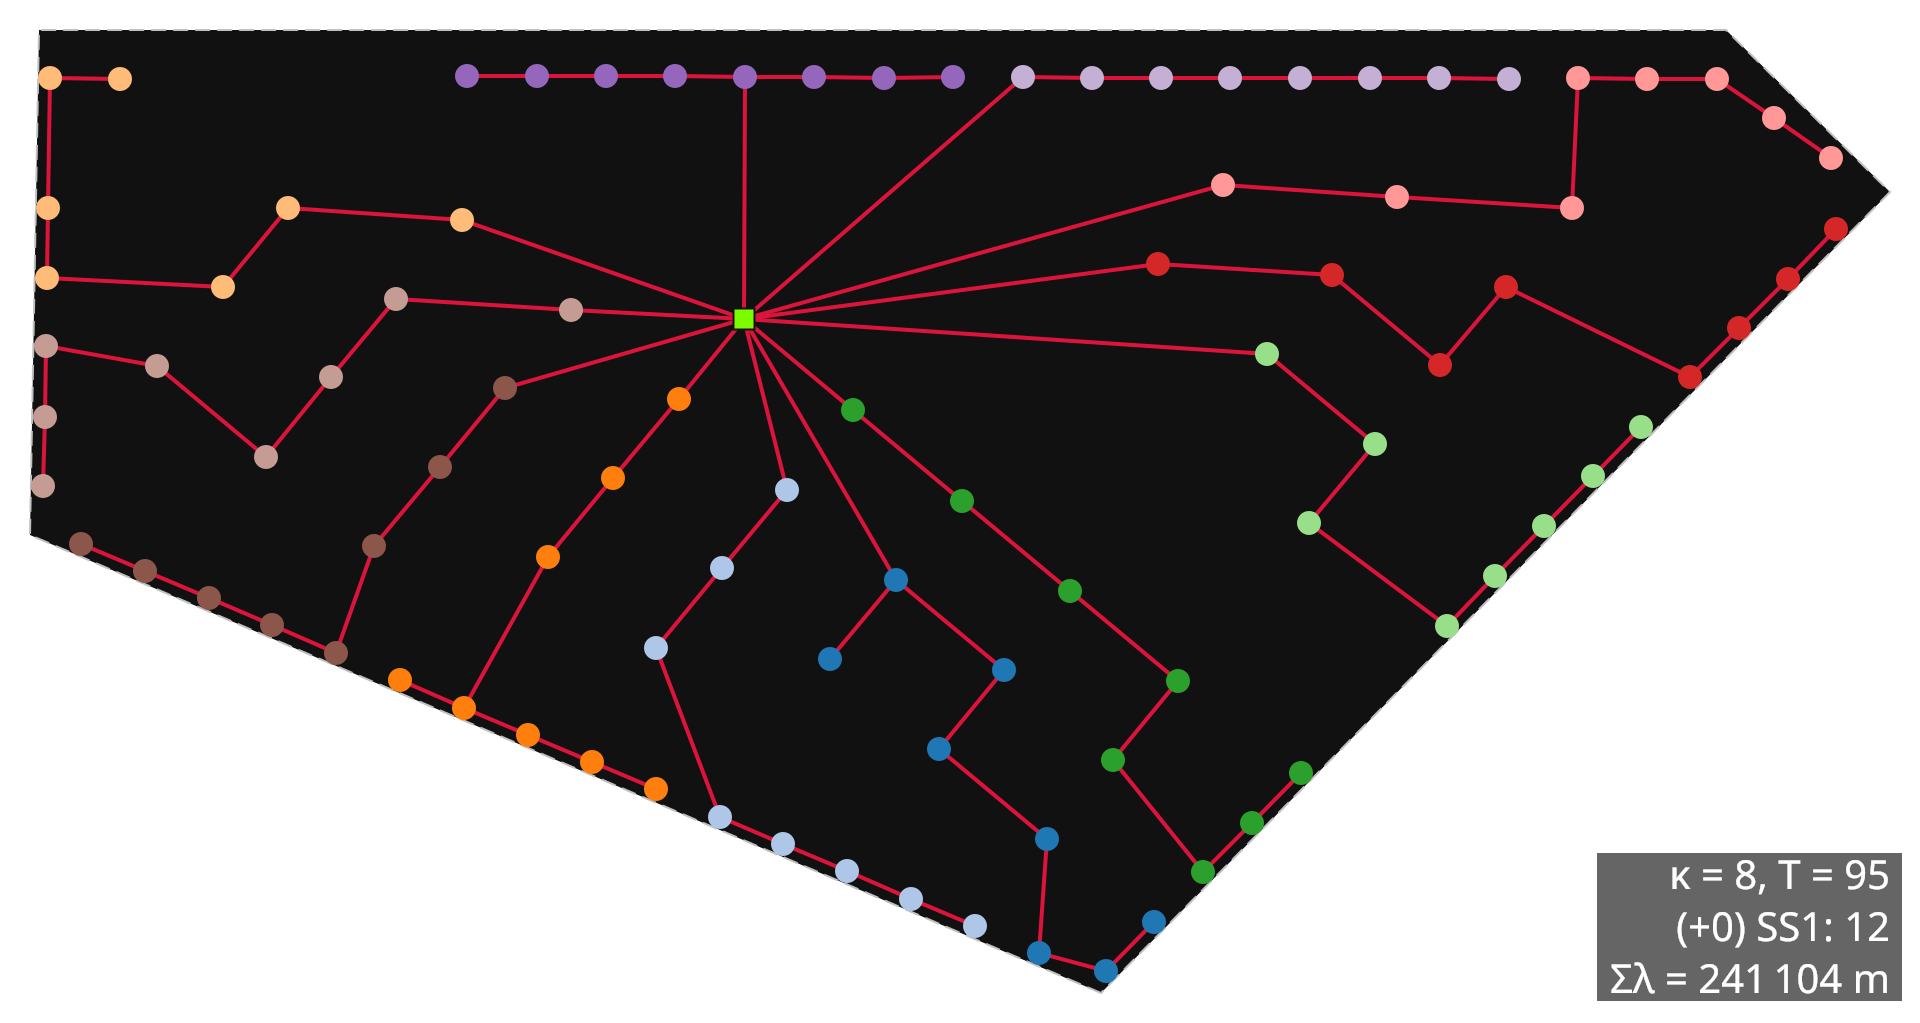

In [25]:
wfn